In [1]:
import warnings
import os
warnings.simplefilter(action='ignore')
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
#parameters

### USER EDIT start
esm_file='/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-03-06-2026/cm3-datastore/cm3-datastore.json'
plotfolder='.'
dpi=300
### USER EDIT stop

import matplotlib as mpl
import os
%matplotlib inline
mpl.rcParams['figure.dpi']= dpi

os.makedirs(plotfolder, exist_ok=True)

 # a similar cell under this means it's being run in batch
print("ESM datastore path: ",esm_file)
print("Plot folder path: ",plotfolder)

ESM datastore path:  /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-03-06-2026/cm3-datastore/cm3-datastore.json
Plot folder path:  .


In [3]:
# Parameters
esm_file = "/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-27-07-2026-PI-control/cm3-datastore/cm3-datastore.json"
plotfolder = "/g/data/tm70/kr4383/Notebooks/access-cm3-paper-1/notebooks/mkfigs_output4/cm3-run-27-07-2026-PI-control/"


In [4]:
import xarray as xr
import cf_xarray as cfxr
import intake
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from distributed import Client
import numpy as np
import iris
import h5py
import dask.array as da

In [5]:
client = Client(threads_per_worker=1)
print(client.dashboard_link)

http://127.0.0.1:8787/status


## Load datastore and datasets

In [6]:
#datastore_path = "/g/data/ol01/access-om3-output/access-om3-025/MC_25km_jra_ryf-1.0-beta/experiment_datastore.json"
COLUMNS_WITH_ITERABLES = [
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units"
]

datastore = intake.open_esm_datastore(
    esm_file,
    columns_with_iterables=COLUMNS_WITH_ITERABLES
)

In [7]:
def get_atm_data(name, dims=('time', 'lat', 'lon')):
    return xr.DataArray(da.concatenate([da.from_array(ds[f"/{name}"]) for ds in atm_ds_list]), dims=dims)
    
atm_fps = datastore.search(variable="fld_s01i208", frequency="1mon").df.sort_values(by='start_date').path.values
atm_ds_list = [h5py.File(fp, "r") for fp in atm_fps]

In [8]:
def get_ice_data(name, dims=('time', 'yh', 'xh')):
    return xr.DataArray(da.concatenate([da.from_array(ds[f"/{name}"]) for ds in ice_ds_list]), dims=dims)
    
ice_fps = sorted(datastore.search(variable="aice_m", frequency="1mon").df.path.values)
ice_ds_list = [h5py.File(fp, "r") for fp in ice_fps]

## Load areas

In [9]:
wet = datastore.search(variable="wet")
wet.df.drop_duplicates(subset='filename', inplace=True)
wet = wet.to_dask().compute()

areacello = datastore.search(variable="areacello")
areacello.df.drop_duplicates(subset='filename', inplace=True)
areacello = areacello.to_dask().compute()

areacello = (areacello.areacello * (wet.wet == 1.0))

In [10]:
EARTH_RADIUS = 6371229.0
nlon, nlat = 192, 144
dx = 360 / nlon
dy = 180 / nlat

element_lat = (np.arange(nlat) + 0.5) * dy  - 90
element_lat = element_lat[:, None] * np.ones(nlon)[None, :]
element_lon = (np.arange(nlon) + 0.5) * dx

pi_over_180 = np.pi / 180
element_areas = dx * pi_over_180 * (
  np.sin((element_lat + 0.5 * dy) * pi_over_180) - np.sin((element_lat - 0.5 * dy) * pi_over_180)
)

areacella = element_areas * EARTH_RADIUS**2
areacella = xr.DataArray(areacella, coords=dict(lat=element_lat[:, 0], lon=element_lon), dims=('lat', 'lon'))

In [11]:
ancil_dir = '/scratch/tm70/kr4383/cylc-run/ancil-gen-22-04-2026/share/data/n96e_mom025_20260316'
land_frac = iris.load_cube(os.path.join(ancil_dir, 'qrparm.landfrac')).data
vsat = iris.load_cube(os.path.join(ancil_dir, 'qrparm.soil'), 'soil_porosity').data

land_area = land_frac * areacella
vsat_area = vsat.data * land_area

## Load different mass components

In [12]:
ocn_mass_daily = datastore.search(variable="masso", frequency="1day").to_dask(
    xarray_open_kwargs = dict(
        decode_timedelta=True
    )
).masso.compute()

ocn_mass_daily = ocn_mass_daily.assign_coords(
    time=ocn_mass_daily.time - np.diff(ocn_mass_daily.time.data)[0]
)

In [13]:
# compute monthly means
ocn_mass = ocn_mass_daily.resample(time='MS').mean()

# shift time coordinate to middle of month
month_start = ocn_mass.time
next_month_start = month_start + ocn_mass.time.dt.days_in_month.astype("timedelta64[D]")
ocn_mass = ocn_mass.assign_coords(
    time=month_start + (next_month_start - month_start) / 2
)

In [14]:
xr_kw = dict(chunks={"yh": -1, "xh": -1}, decode_timedelta=True)
pseudo_iceberg_flux = datastore.search(variable="ficeberg", frequency="1mon").to_dask(xarray_open_kwargs=xr_kw).ficeberg

In [15]:
%%time
pseudo_iceberg_avg_monthly_flux = pseudo_iceberg_flux.weighted(areacello.fillna(0)).sum(dim=('yh', 'xh')).compute()
pseudo_iceberg_mass = (pseudo_iceberg_avg_monthly_flux * pseudo_iceberg_avg_monthly_flux.time.dt.days_in_month * 24 * 3600).cumsum()

pseudo_iceberg_mass.data[1:] = pseudo_iceberg_mass.data[:-1]
pseudo_iceberg_mass.data[0] = 0.0

CPU times: user 1.13 s, sys: 903 ms, total: 2.03 s
Wall time: 3.08 s


In [16]:
atm_total_mass = get_atm_data('fld_s30i404').weighted(areacella).sum(dim=('lat', 'lon')).compute()
atm_dry_mass = get_atm_data('fld_s30i403').weighted(areacella).sum(dim=('lat', 'lon')).compute()
atm_water_mass = atm_total_mass - atm_dry_mass

In [17]:
land_snow_mass = get_atm_data('fld_s08i023').weighted(land_area).sum(dim=('lat', 'lon')).compute()
soil_water_mass = get_atm_data('fld_s08i223', dims=('time', 'depth', 'lat', 'lon')).weighted(land_area).sum(dim=('lat', 'lon', 'depth')).compute()
river_mass = get_atm_data('fld_s26i001', dims=('time', 'lat_river', 'lon_river')).sum(dim=('lat_river', 'lon_river')).compute()
ground_water_mass = 3000 * get_atm_data('fld_s08i250').weighted(vsat_area).sum(dim=('lat', 'lon')).compute()

In [18]:
%%time
sea_ice_vol = get_ice_data('hi_m').weighted(areacello.fillna(0)).sum(dim=('yh', 'xh')).compute()
sea_snow_vol = get_ice_data('hs_m').weighted(areacello.fillna(0)).sum(dim=('yh', 'xh')).compute()

CPU times: user 13.8 s, sys: 13.3 s, total: 27.1 s
Wall time: 1min 39s


In [19]:
# CICE ice and snow densities
rhoi = 917.
rhos = 330.
ocean_density = 1026.

In [20]:
sea_ice_mass = rhoi * sea_ice_vol + rhos * sea_snow_vol
sea_ice_mass = sea_ice_mass.assign_coords(time=ocn_mass.time)

atm_mass = atm_water_mass + land_snow_mass + soil_water_mass + river_mass + ground_water_mass
atm_mass = atm_mass.assign_coords(time=ocn_mass.time)

In [21]:
total_mass = sea_ice_mass + atm_mass + ocn_mass - pseudo_iceberg_mass

Text(0.5, 1.0, 'Water mass error (mm)')

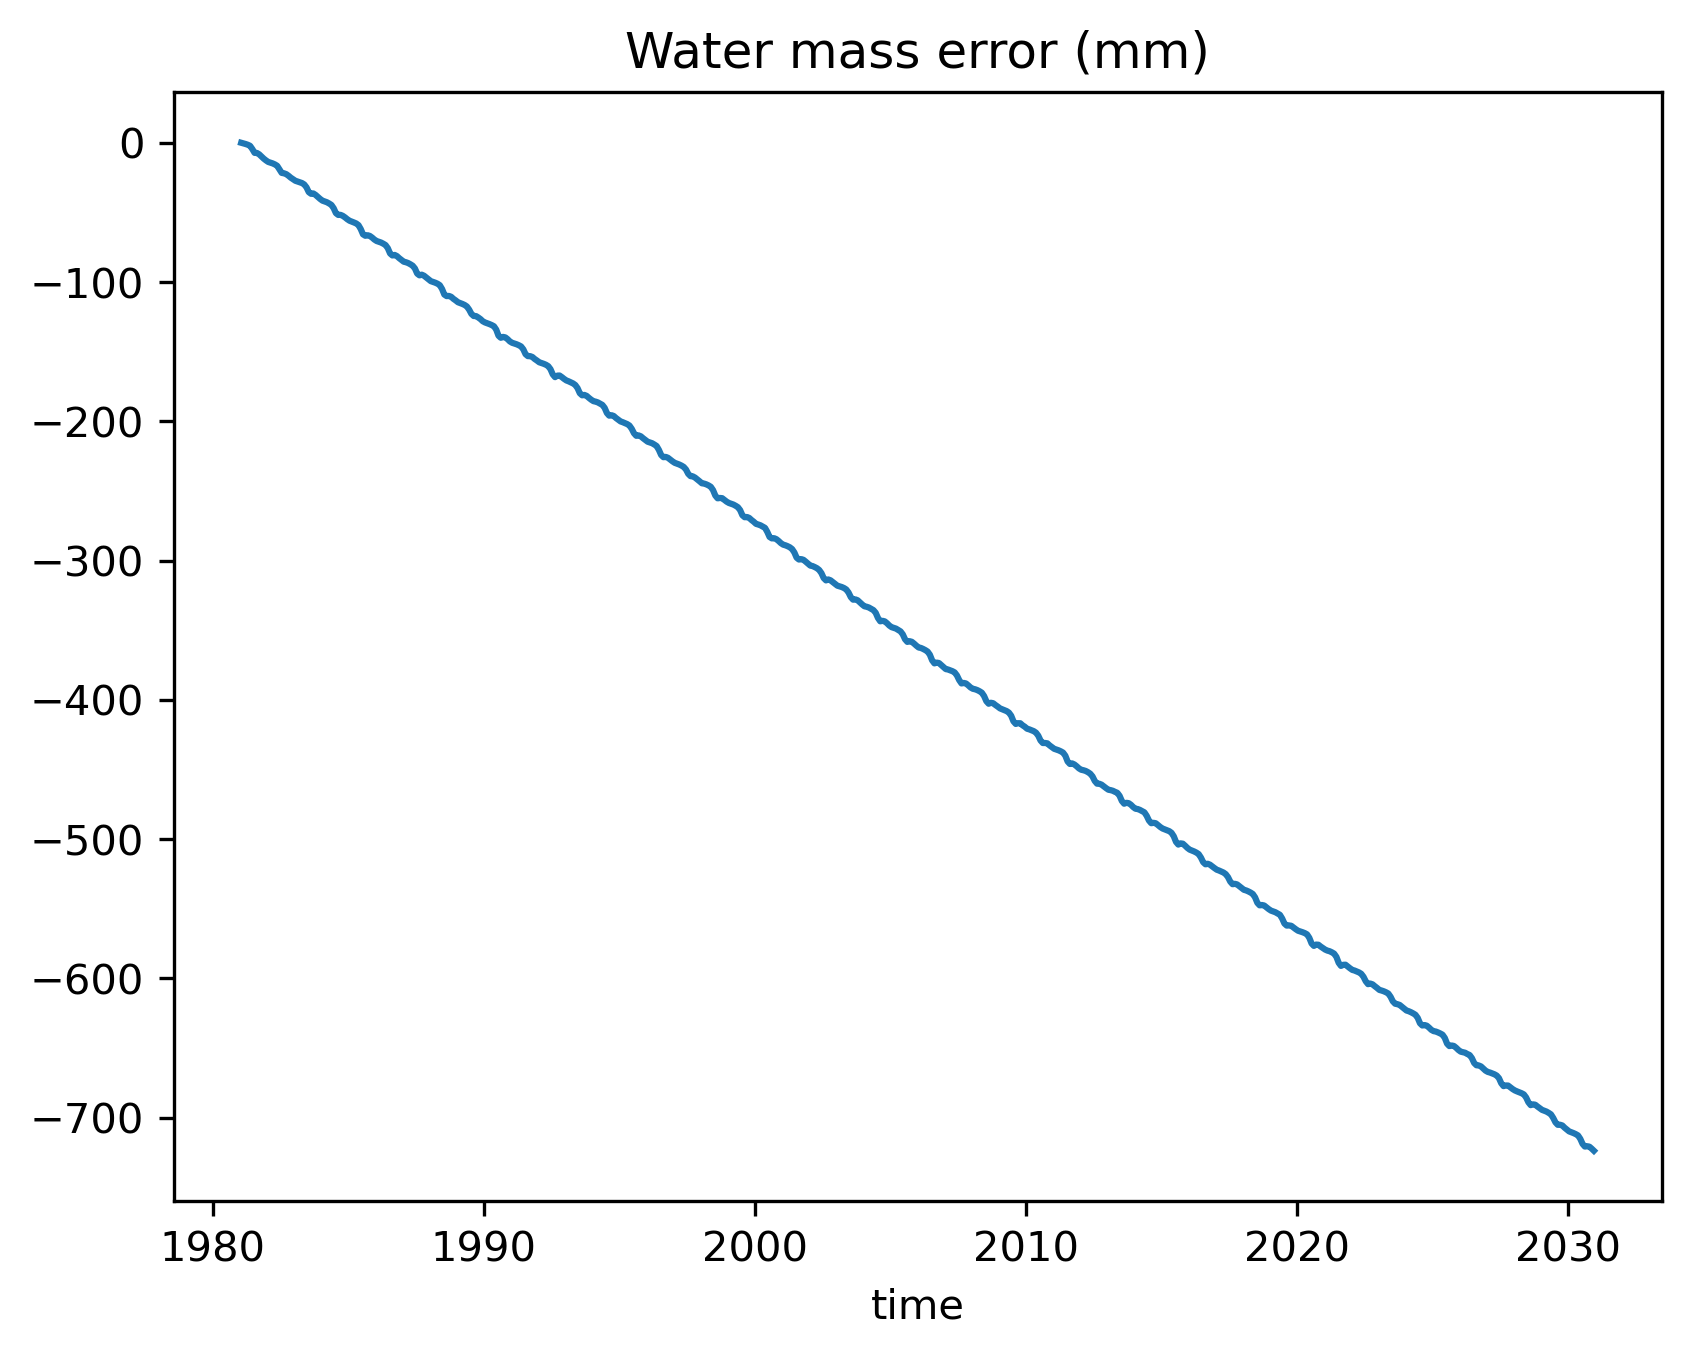

In [22]:
mass_error_mm = (total_mass - total_mass[0]) * 1000 / (ocean_density * areacello.sum())
mass_error_mm.plot()
plt.title('Water mass error (mm)')

Text(0.5, 1.0, 'Relative water mass error')

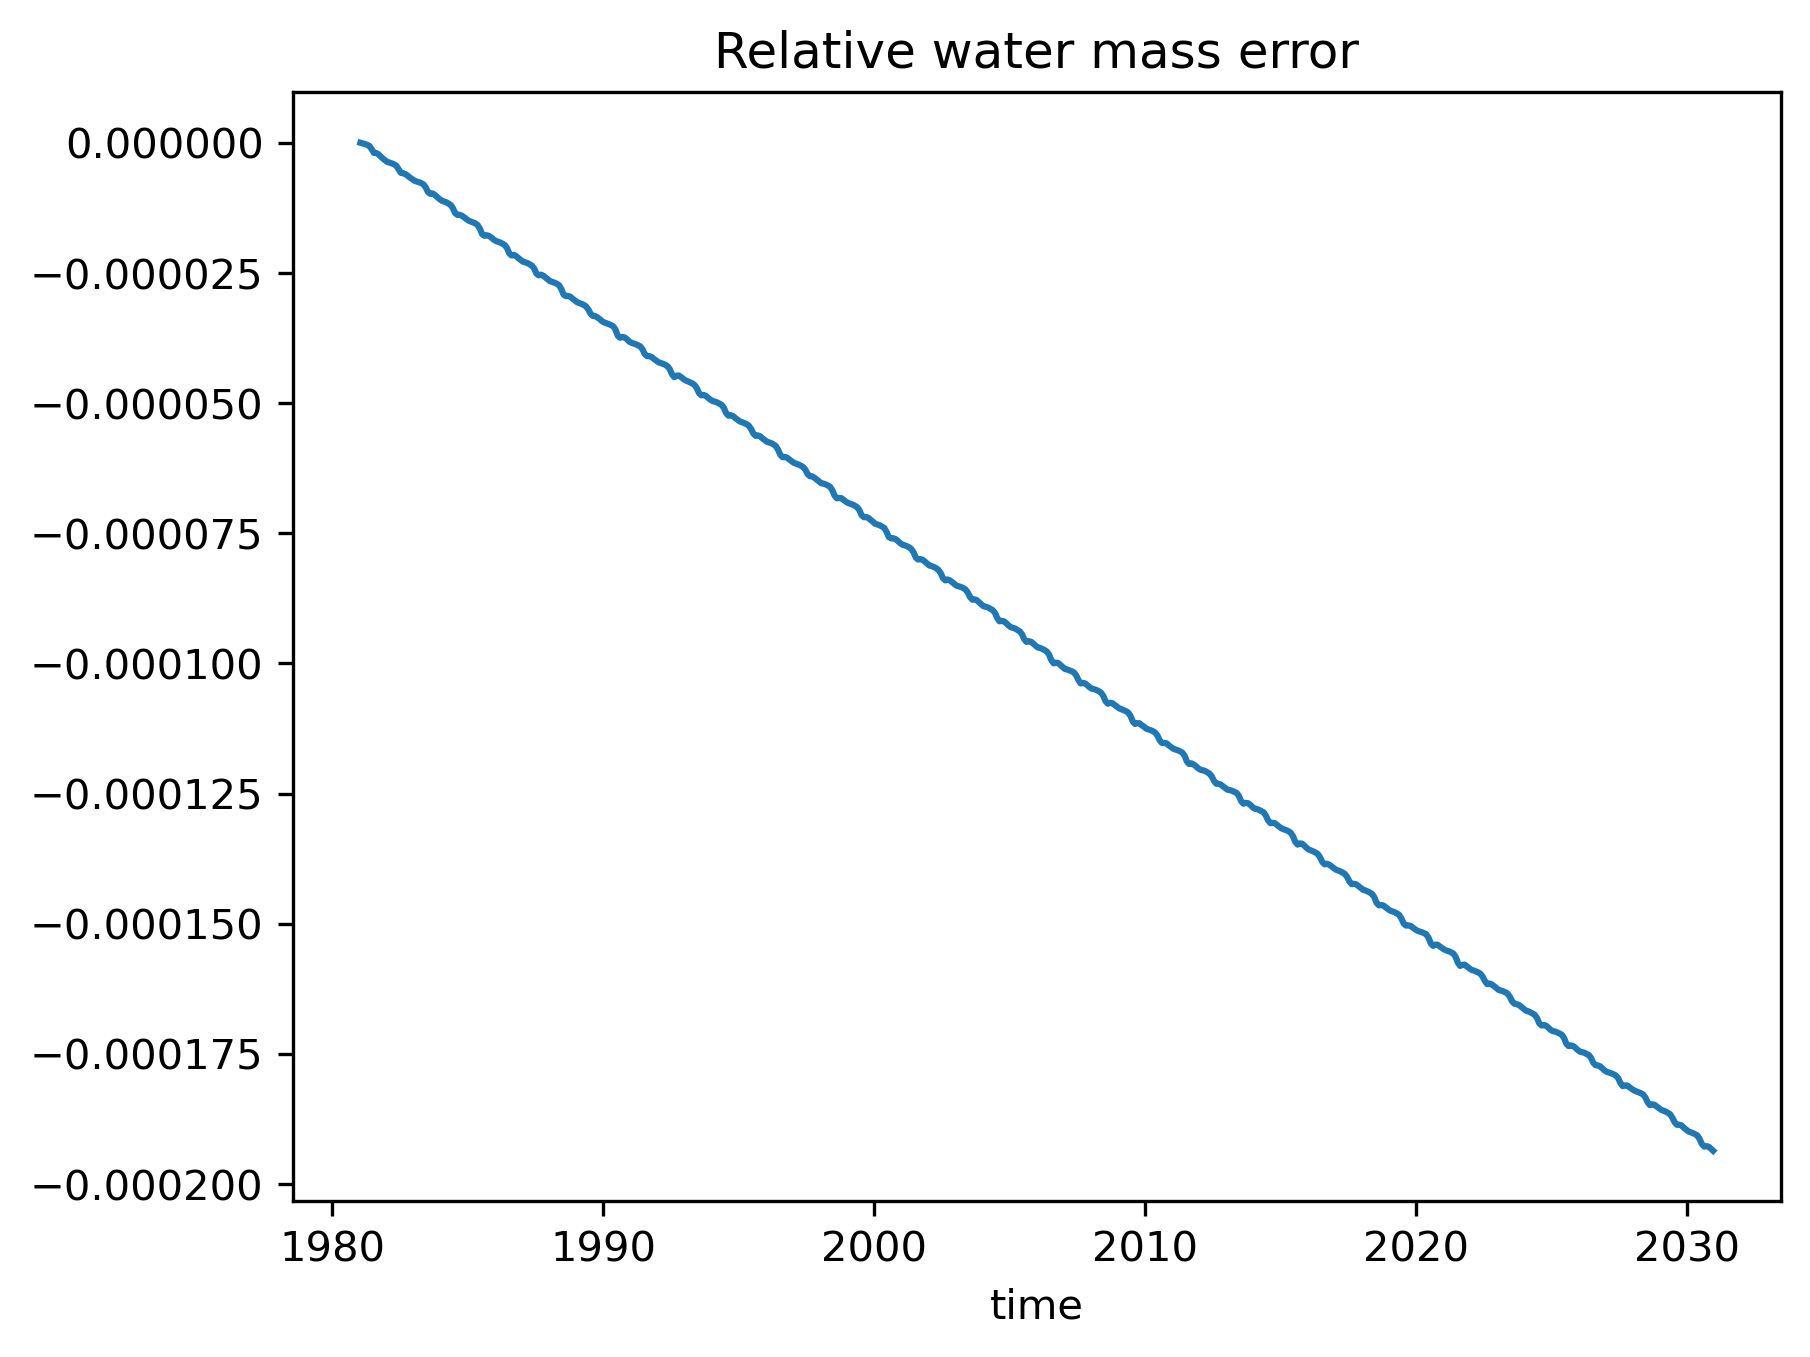

In [23]:
relative_mass_error = (total_mass - total_mass[0]) / total_mass[0]
relative_mass_error.plot()
plt.title('Relative water mass error')